In [1]:
%run stochastic_lite.ipynb

In [2]:
deltaF=0.25
segmentDuration=64

## Noise only

In [3]:
dat=np.load('../data/colored_noise_H1.npy')
t1,h1=dat[:,0],dat[:,1]
d1=TimeSeries(t1,h1)

dat=np.load('../data/colored_noise_H2.npy')
t2,h2=dat[:,0],dat[:,1]
d2=TimeSeries(t2,h2)

jobDuration=d2.times[-1]-d2.times[0]+d2.deltaT

#######################
deltaT = d1.deltaT
fNyquist = 1/(2*deltaT)
nperseg = int(fNyquist/deltaF)
freqs = np.linspace(0, fNyquist, nperseg)
f_filter = freqs>21.

3600.0
64
4096.0


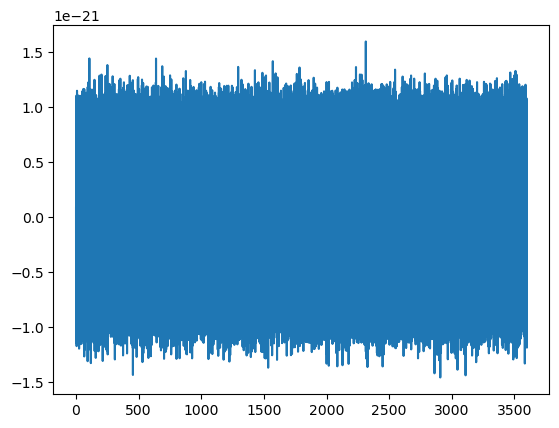

In [4]:
plt.plot(t1, h1)
print(jobDuration)
print(segmentDuration)
print(d1.Fs)

In [5]:
nperseg=int(d1.Fs/deltaF)
freqs,P1_test = welch_psd(d1.data,nperseg=nperseg,window='Hann',fs=d1.Fs)
freqs,P2_test = welch_psd(d2.data,nperseg=nperseg,window='Hann',fs=d2.Fs)

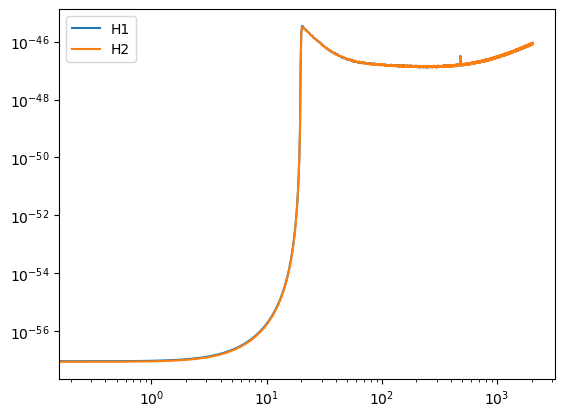

In [6]:
plt.loglog(freqs,P1_test,label='H1')
plt.loglog(freqs,P2_test,label='H2')
plt.legend()

In [7]:
Ys, sigs, Y_fs, var_fs, Y0_fs, var0_fs, segmentStartTimes, freqs=stochastic(d1,
                                                                            d2,
                                                                            segmentDuration,
                                                                            deltaF,
                                                                            f_filter,
                                                                            verbose=False,
                                                                            doOverlap=True,
                                                                            alpha=2/3,
                                                                            fref=25,
                                                                            orf_file=None)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:109: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3))
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:110: RuntimeWarning: invalid value encountered in multiply
  S_alpha = FrequencySeries(freqs, S0.data * (freqs/fref)**alpha )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  Y0_fs[:,II],var0_fs[:,II] = Y0_f.data, var0_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:131: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II], sigs[

In [8]:
# combine point estimates and error bars assuming that stochastic was run with fixed alpha
deltaT = d1.deltaT
Y_opt, sig_opt = postprocessing(Ys,sigs,jobDuration,segmentDuration,deltaF,deltaT,bufferSecs=0)

print('Y_opt =', Y_opt)
print('sig_opt =', sig_opt)

Y_opt = 2.427713180896863e-09
sig_opt = 1.0656199858942143e-08


In [9]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaF,d1.deltaT)

Y0_f,var0_f=postprocessing_spectra(Y0_fs,var0_fs,jobDuration,segmentDuration,
                                 deltaF,d1.deltaT)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:28: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:29: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:33: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:34: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:43: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331

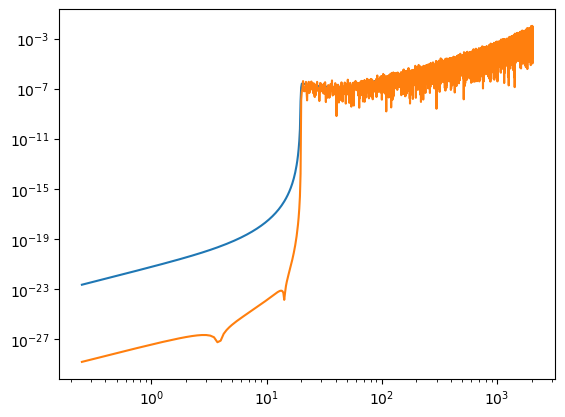

In [10]:
plt.loglog(freqs,np.sqrt(var_f))
plt.loglog(freqs,np.abs(Y_f))

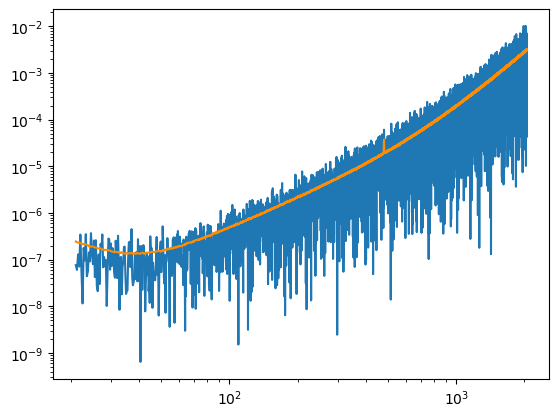

In [11]:
plt.loglog(freqs[f_filter],np.abs(Y_f[f_filter]))
plt.loglog(freqs[f_filter],np.sqrt(var_f[f_filter]), color='darkorange')


In [12]:
# compute optimal SNR

y,s=calc_Y_sigma_from_Yf_varf(np.real(Y0_f[f_filter]),
                          var0_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=2./3,
                          fref=25)
print('y=', y)
print('s=', s)
print('Optimal SNR [alpha=2/3]: %f'%(y/s))

# Y_f, var_f and Y0_f, var0_f should be the same

y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=None)

print('y=', y)
print('s=', s)
print('Optimal SNR [alpha=2/3]: %f'%(y/s))

y= 2.426633425900141e-09
s= 1.065602746221612e-08
Optimal SNR [alpha=2/3]: 0.227724
y= 2.4266336370592902e-09
s= 1.0656027501872242e-08
Optimal SNR [alpha=2/3]: 0.227724


Text(0, 0.5, 'SNR')

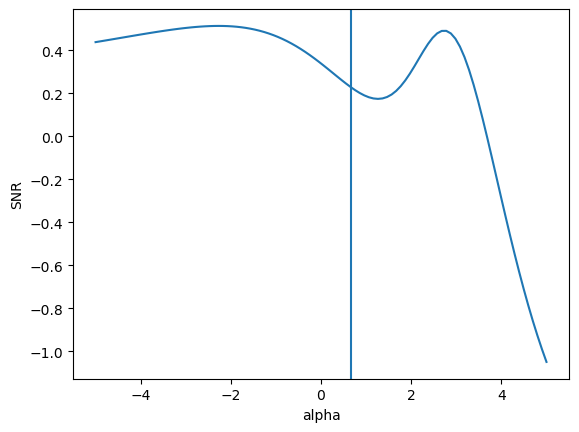

In [13]:
alphas=np.linspace(-5,5,100)

snrs=np.zeros(alphas.shape)
for ii,a in enumerate(alphas):
    y,s=calc_Y_sigma_from_Yf_varf(np.real(Y0_f[f_filter]),
                          var0_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=a,
                          fref=25)
    snrs[ii]=y/s
plt.plot(alphas,snrs)
plt.axvline(2./3)
plt.xlabel('alpha')
plt.ylabel('SNR')

20:03 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
20:03 bilby INFO    : Analysis priors:
20:03 bilby INFO    : A=LogUniform(minimum=1e-08, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
20:03 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
20:03 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
20:03 bilby INFO    : Analysis likelihood noise evidence: 42804.90317763692
20:03 bilby INFO    : Single likelihood evaluation took 1.079e-04 s
20:03 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None

2510it [00:05, 360.03it/s, bound:21 nc: 18 ncall:3.0e+04 eff:8.4% logz-ratio=-2.69+/-0.20 dlogz:0.106>0.1]        

20:03 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


2539it [00:06, 362.74it/s, bound:22 nc:  1 ncall:3.1e+04 eff:10.0% logz-ratio=-2.59+/-0.06 dlogz:0.000>0.1]

20:03 bilby INFO    : Rejection sampling nested samples to obtain 872 posterior samples
20:03 bilby INFO    : Sampling time: 0:00:06.996582
20:03 bilby INFO    : Summary of results:
nsamples: 872
ln_noise_evidence: 42804.903
ln_evidence: 42802.314 +/-  0.087
ln_bayes_factor: -2.589 +/-  0.087



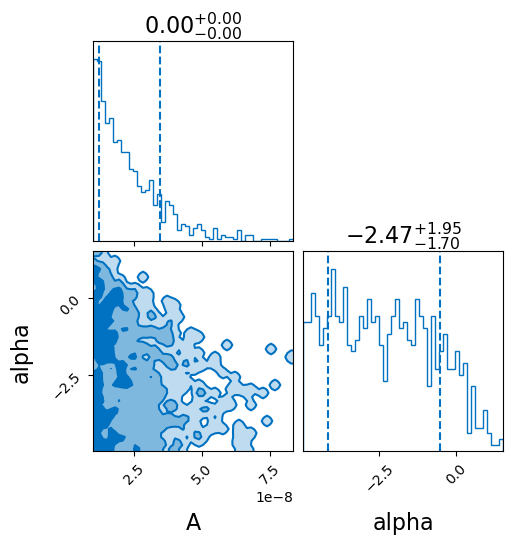

In [14]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-8,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y0_f[f_filter],var0_f[f_filter],freqs[f_filter],fref)
priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

## Noise + CBCs


In [15]:
dat=np.load('../data/colored_noise_plus_signal_H1.npy')
t1,h1=dat[:,0],dat[:,1]
d1=TimeSeries(t1,h1)

dat=np.load('../data/colored_noise_plus_signal_H2.npy')
t2,h2=dat[:,0],dat[:,1]
d2=TimeSeries(t2,h2)

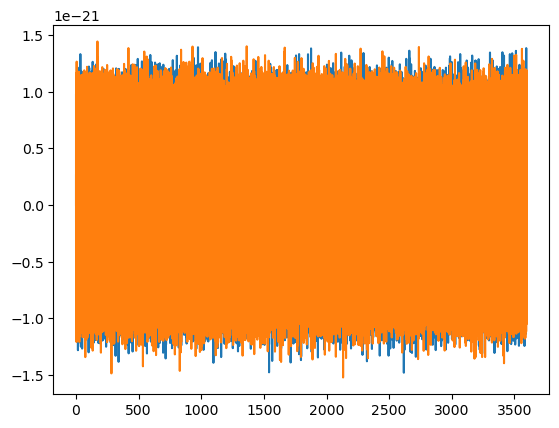

In [16]:
plt.figure()
plt.plot(t1,h1)
plt.plot(t2,h2)

In [17]:
nperseg=int(d1.Fs/deltaF)
freqs,P1_test = welch_psd(d1.data,nperseg=nperseg,window='Hann',fs=d1.Fs)
freqs,P2_test = welch_psd(d2.data,nperseg=nperseg,window='Hann',fs=d2.Fs)

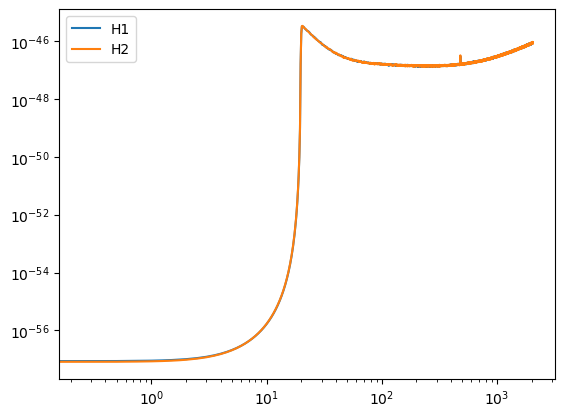

In [18]:
plt.loglog(freqs,P1_test,label='H1')
plt.loglog(freqs,P2_test,label='H2')
plt.legend()

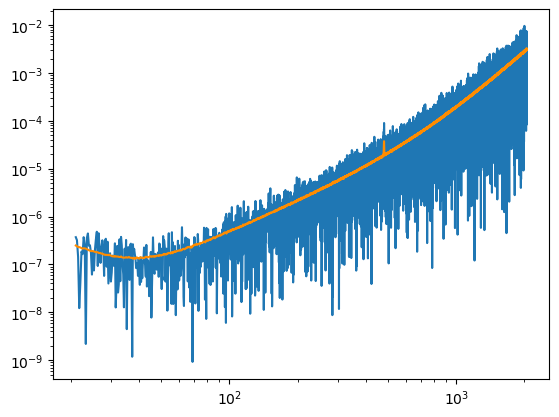

In [31]:
plt.loglog(freqs[f_filter],np.abs(Y_f[f_filter]))
plt.loglog(freqs[f_filter],np.sqrt(var_f[f_filter]), color='darkorange')

In [19]:
Ys,sigs,Y_fs,var_fs,Y0_fs,var0_fs,segmentStartTimes,freqs=stochastic(d1,
                                                       d2,
                                                       segmentDuration,
                                                       deltaF,
                                                       f_filter,
                                                       verbose=False,
                                                       doOverlap=True,
                                                       alpha=2/3,
                                                       fref=25,
                                                       orf_file=None)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:109: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3))
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:110: RuntimeWarning: invalid value encountered in multiply
  S_alpha = FrequencySeries(freqs, S0.data * (freqs/fref)**alpha )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  Y0_fs[:,II],var0_fs[:,II] = Y0_f.data, var0_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:131: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/2696842887.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II], sigs[

In [20]:
print(Ys, sigs)

[ 4.03700895e-07 -2.80224211e-09 -1.02462770e-07  9.90099472e-08
  1.25953403e-07 -4.13029217e-08  3.66245416e-09  1.41423412e-07
 -4.40824086e-08  1.77643820e-07  1.07703382e-08  6.24372450e-08
  6.08519326e-09  1.36476933e-07  1.67059466e-07  1.57499759e-07
  6.13099413e-09 -4.96293510e-08  4.39684596e-08  1.51012668e-07
  8.86808560e-08  3.05351332e-08  2.74582631e-07  2.16943520e-07
  3.16502404e-08  6.88004293e-08  2.15675542e-07 -1.97499087e-08
  1.87542722e-07  1.85480569e-07  2.18588534e-07 -1.48612004e-07
 -2.32327863e-07 -1.93641015e-08  1.61437981e-08 -1.14968335e-07
 -7.44963487e-08  6.12433933e-08 -4.26960696e-09  1.10895289e-07
 -4.21296941e-08  5.59424600e-08  4.37461609e-08  7.24583961e-08
  1.61242610e-07  1.18361317e-07  3.88415686e-08  2.37782234e-07
  1.19640635e-07 -1.24579057e-08 -1.61457925e-07 -8.00864928e-08
  1.36335482e-09  3.37721521e-08 -1.85204533e-07  5.96300434e-08
  5.35432999e-08 -8.96612825e-08  1.05188219e-07  1.34308563e-09
 -1.15654470e-07  8.98613

In [21]:
# combine point estimates and error bars
deltaT = d1.deltaT
Y_opt,sig_opt = postprocessing(Ys,sigs,jobDuration,segmentDuration,deltaF,deltaT,bufferSecs=0)

print('Y_opt =', Y_opt)
print('sig_opt =', sig_opt)

Y_opt = 4.805500275993778e-08
sig_opt = 1.0707981868127659e-08


In [22]:
# combine spectra over times

Y0_f,var0_f=postprocessing_spectra(Y0_fs,var0_fs,jobDuration,segmentDuration,
                                 deltaF,d1.deltaT)

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaF,d1.deltaT)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:28: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:29: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:33: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:34: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331911.py:43: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_76042/1643331

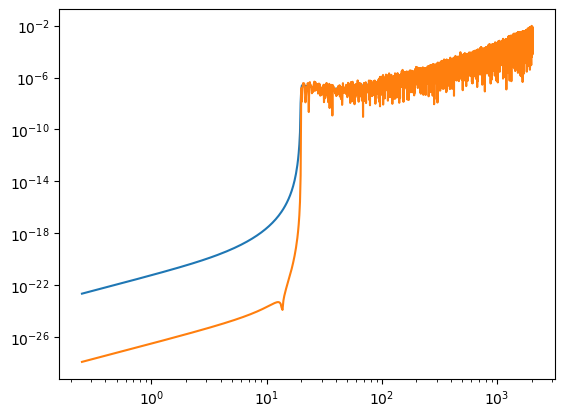

In [23]:
plt.loglog(freqs,np.sqrt(var_f))
plt.loglog(freqs,np.abs(Y_f))

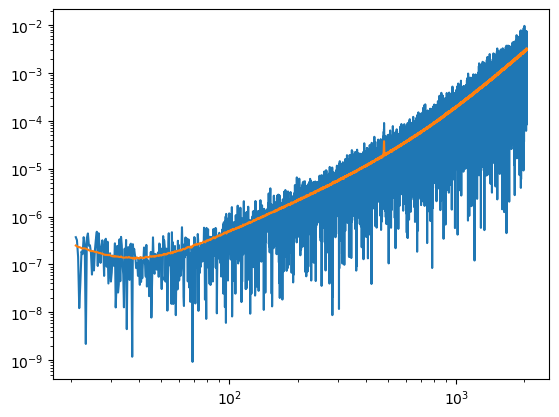

In [24]:
plt.loglog(freqs[f_filter],np.abs(Y_f[f_filter]))
plt.loglog(freqs[f_filter],np.sqrt(var_f[f_filter]))


In [25]:
# compute optimal SNR (alternate calculation)

y_opt,s_opt=calc_Y_sigma_from_Yf_varf(np.real(Y0_f[f_filter]),
                          var0_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=2./3,
                          fref=25)

print(y_opt, s_opt)
print('Optimal SNR [alpha=2/3]: %f'%(y_opt/s_opt))

################################################
# compute optimal SNR

y_opt,s_opt=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs = None)

print(y_opt, s_opt)
print('Optimal SNR [alpha=2/3]: %f'%(y_opt/s_opt))

4.806411149846715e-08 1.0708140662412482e-08
Optimal SNR [alpha=2/3]: 4.488558
4.806410301436724e-08 1.0708140517279375e-08
Optimal SNR [alpha=2/3]: 4.488557


Text(0, 0.5, 'SNR')

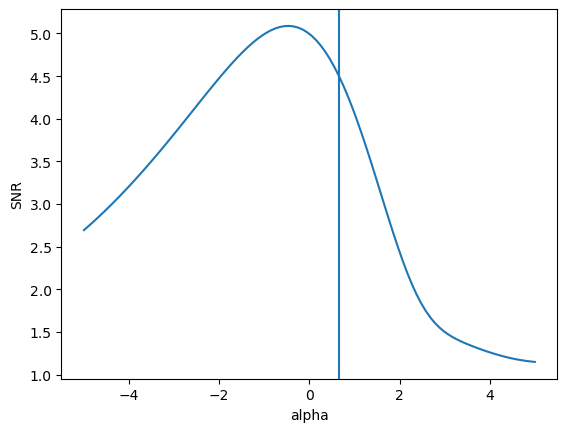

In [26]:
alphas=np.linspace(-5,5,100)

snrs=np.zeros(alphas.shape)
for ii,a in enumerate(alphas):
    y,s=calc_Y_sigma_from_Yf_varf(np.real(Y0_f[f_filter]),
                          var0_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=a,
                          fref=25)
    snrs[ii]=y/s
plt.plot(alphas,snrs)
plt.axvline(2./3)
plt.xlabel('alpha')
plt.ylabel('SNR')

20:04 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
20:04 bilby INFO    : Analysis priors:
20:04 bilby INFO    : A=LogUniform(minimum=1e-08, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
20:04 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
20:04 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
20:04 bilby INFO    : Analysis likelihood noise evidence: 42813.3239103704
20:04 bilby INFO    : Single likelihood evaluation took 1.058e-04 s
20:04 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None,

3653it [00:11, 223.39it/s, bound:65 nc: 20 ncall:5.7e+04 eff:6.4% logz-ratio=7.83+/-nan dlogz:0.108>0.1]         

20:04 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


3687it [00:13, 272.23it/s, bound:66 nc:  1 ncall:5.8e+04 eff:7.2% logz-ratio=7.93+/-0.09 dlogz:0.000>0.1]

20:04 bilby INFO    : Rejection sampling nested samples to obtain 1496 posterior samples
20:04 bilby INFO    : Sampling time: 0:00:13.539957
20:04 bilby INFO    : Summary of results:
nsamples: 1496
ln_noise_evidence: 42813.324
ln_evidence: 42821.253 +/-  0.113
ln_bayes_factor:  7.929 +/-  0.113



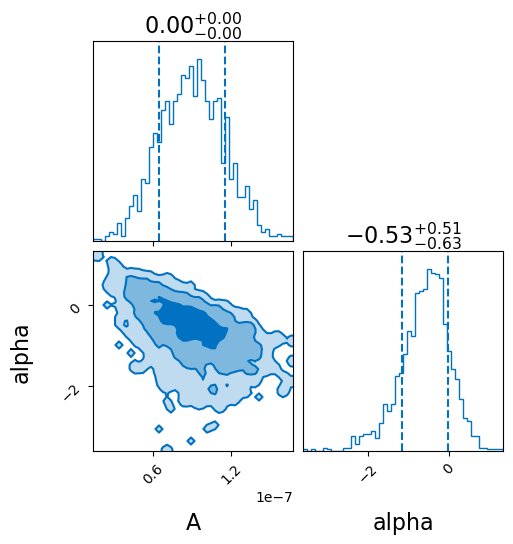

In [27]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-8,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y0_f[f_filter],var0_f[f_filter],freqs[f_filter],fref)
priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

In [28]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

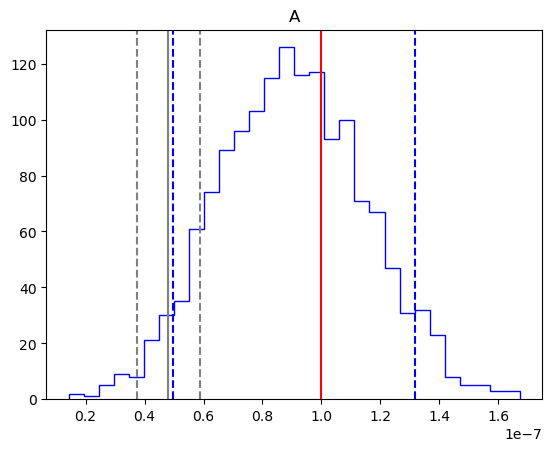

In [29]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(1e-7,color='red')
plt.axvline(y_opt,color='grey')
plt.axvline(y_opt-s_opt,color='grey',linestyle='--')
plt.axvline(y_opt+s_opt,color='grey',linestyle='--')

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

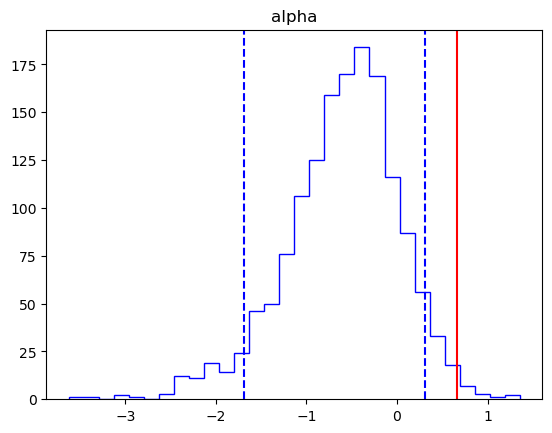

In [30]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(2./3,color='red')

plt.title('alpha')
plt.xlabel('')